In [1]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match",
    "The bowler delivered a fast yorker to take the wicket",
    "The team won the match by chasing a huge target",
    "The captain set an aggressive field during the game",

    # Cooking
    "The chef prepared a delicious pasta with fresh ingredients",
    "Baking a cake requires precise measurements and timing",
    "The recipe includes spices and herbs for better flavor",

    # Cybersecurity
    "Strong passwords help protect against cyber attacks",
    "Encryption ensures that sensitive data remains secure",
    "Firewalls are essential for network security"
]

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)
print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (10, 384)


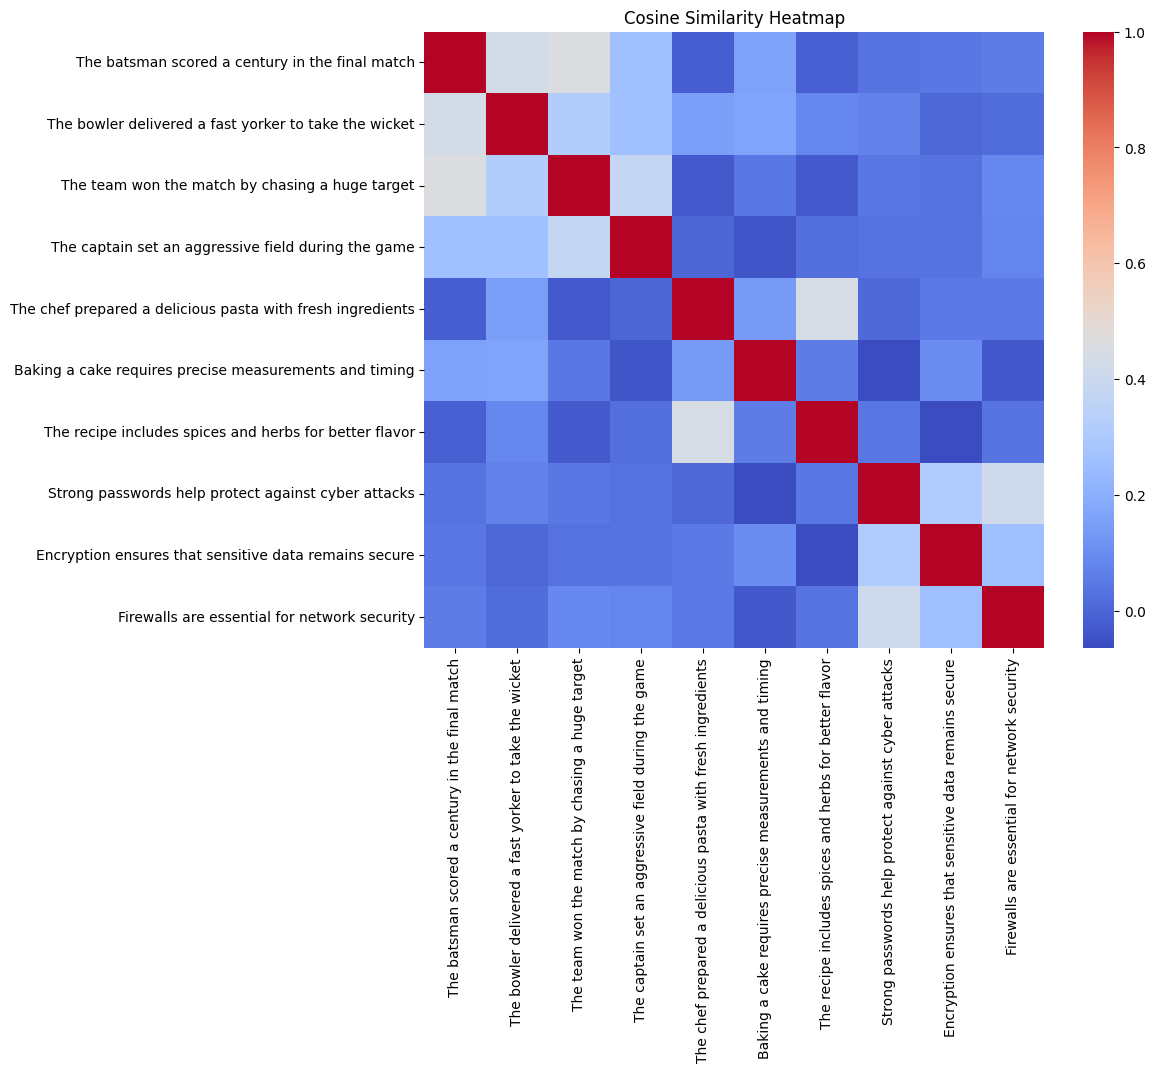

In [5]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=False, cmap='coolwarm')
plt.title("Cosine Similarity Heatmap")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = similarities.argsort()[-2:][::-1]

print("Query:", query)
print("\nTop 2 similar sentences:\n")

for idx in top_indices:
    print(f"Sentence: {sentences[idx]}")
    print(f"Similarity Score: {similarities[idx]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 similar sentences:

Sentence: The bowler delivered a fast yorker to take the wicket
Similarity Score: 0.6663

Sentence: The batsman scored a century in the final match
Similarity Score: 0.5707

